# K Nearest Neighbors Algorithm Example Implementation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rice_ml.Supervised_Learning.knn_class import KNearestNeighbors

from rice_ml.processing.preprocessing import train_test_split, standardize, normalize
from rice_ml.processing.postprocessing import PostProcessor

# Set the Seaborn theme
sns.set_theme()

# Reading in the Spam Email Dataset
from pathlib import Path
import pandas as pd
_spam_paths = []
for _root in [Path.cwd(), *Path.cwd().parents]:
    _spam_paths.append(_root / 'examples' / 'datasets' / 'spam_email_dataset.csv')
    _spam_paths.append(_root / 'datasets' / 'spam_email_dataset.csv')
for _p in _spam_paths:
    if _p.is_file():
        df = pd.read_csv(_p)
        break
else:
    raise FileNotFoundError('spam_email_dataset.csv — open notebook from repo or examples/.')


/Users/ccarr21/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


# Visualizing the Spam Email Dataset

In [ ]:
# Visualize the dataset 

# Scatter plot of num_words vs num_links colored by label
plt.figure(figsize=(6, 3.5))
sns.scatterplot(data=df, x="num_words", y="num_links", hue="label")
plt.title("Spam Email Dataset")
plt.xlabel("Number of Words")
plt.ylabel("Number of Links")
plt.legend(title="Label", loc="upper right")
plt.tight_layout()
plt.show()

# Histograms of num_attachments and num_links colored by label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="num_attachments", hue="label", multiple="dodge", shrink=0.8)
plt.title("Spam Email Dataset")
plt.xlabel("Number of Attachments")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="num_links", hue="label", multiple="dodge", shrink=0.8)
plt.xlabel("Number of Links")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="num_words", hue="label", multiple="dodge", shrink=0.8)
plt.ylim(0, 800)
plt.xlabel("Number of Words")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="sender_reputation_score", hue="label", multiple="dodge", shrink=0.8)
plt.xlabel("Reputation Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Missing values in the dataset
print("Missing Values per Column:")
print(df.isnull().sum().to_markdown())


# Preprocessing
Standardization or Normalization available for scaling.

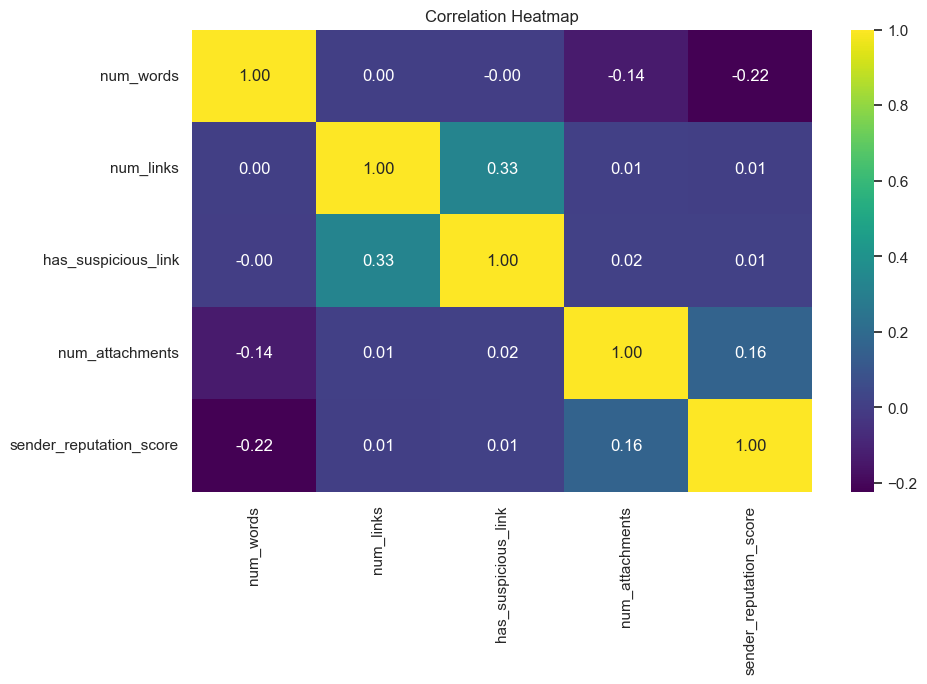

In [2]:
# Selecting features and target variable
features = ["num_words", "num_links", "has_suspicious_link","num_attachments", "sender_reputation_score"]
target = "label"
X = df[features].values
y = df[target].values
# Correlation heatmap of the features
corr_map = df[features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verifying the shapes of the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")
# Scaling the features
X_train, X_test = standardize(X_train, X_test)
# Instantiating and training the Classifier and Regressor
knn_classifier = KNearestNeighbors(n_neighbors=5, task="classification")
knn_regressor = KNearestNeighbors(n_neighbors=5, task="regression")
knn_classifier.fit(X_train, y_train)
knn_regressor.fit(X_train, y_train)

print("kNN Classifier trained successfully.")
print("kNN Regressor trained successfully.")

Training features shape: (8000, 5)
Testing features shape: (2000, 5)
Training labels shape: (8000,)
Testing labels shape: (2000,)
kNN Classifier trained successfully.
kNN Regressor trained successfully.


# Prediction and Evaluation
Classification Method better suited for this dataset.

In [ ]:
processor = PostProcessor()
# Generate predictions on the test set for visualization
knn_classifier_pred = knn_classifier.predict(X_test)
knn_regressor_pred = knn_regressor.predict(X_test)

# Classification Report: kNN Classifier
report = processor.classification_metrics(y_test, knn_classifier_pred)
print(f"Classification Metrics: ", report)
# Accuracy of the kNN Classifier
accuracy = processor.accuracy(y_test, knn_classifier_pred)
print(f"Accuracy: ", accuracy)

# Regression Report: kNN Regressor
report = processor.regression_metrics(y_test, knn_regressor_pred)
print(f"Regression Metrics: ", report)
# Accuracy of the kNN Regressor
acc = processor.accuracy(y_test, knn_regressor_pred)
print(f"Accuracy: ", acc)


Classification Metrics:  {'classification_error': 0.2165, 'precision': 0.7224287484510533, 'recall': 0.7361111111111112, 'f1_score': 0.7292057535959975, 'confusion_matrix': array([[984, 224],
       [209, 583]])}
Accuracy:  0.7835
Regression Metrics:  {'mae': 0.23310000000000003, 'mse': 0.14526000000000003, 'rmse': 0.38112989911577394, 'r2': 0.39268512944009626, 'sst': 478.36800000000005, 'ssr': 187.848, 'sse': 290.52000000000004, 'df_regression': 1.0, 'df_error': 1998.0, 'df_total': 1999.0, 'ms_regression': 187.848, 'ms_error': 0.14540540540540542, 'f_statistic': 1291.8914498141264}
Accuracy:  0.5265
